In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Т5
## Генерация выборки (n=100)

In [54]:
theta = 10
n = 100
beta = 0.95
np.random.seed(69)
sample = np.random.uniform(theta, 2 * theta, n)

x_mean = np.mean(sample)
x_max = np.max(sample)

## Точный интервал

In [55]:
lower_exact = x_max / (1 + ((1 + beta) / 2) ** (1 / n))
upper_exact = x_max / (1 + ((1 - beta) / 2) ** (1 / n))

print(f"Точный интервал: [{lower_exact:.3f}, {upper_exact:.3f}], ширина: {upper_exact - lower_exact:.3f}")

Точный интервал: [9.940, 10.122], ширина: 0.182


## Асимптотический интервал

In [56]:
theta_mm = (2/3) * x_mean
u = norm.ppf((1 + beta) / 2)
lower_asym = theta_mm * (1 - u / np.sqrt(27 * n))
upper_asym = theta_mm * (1 + u / np.sqrt(27 * n))
print(f"Асимптотический интервал: [{lower_asym:.3f}, {upper_asym:.3f}], ширина: {upper_asym - lower_asym:.3f}")

Асимптотический интервал: [9.344, 10.077], ширина: 0.733


## Бутстраповский интервал

### по ОММ

In [57]:
N = 50000
theta_mm = (2/3) * x_mean

deltas_mm_nonparam = np.zeros(N)
deltas_mm_param = np.zeros(N)

for i in range(N):
    # 1. Непараметрический: из самой выборки с возвращением
    boot_np = np.random.choice(sample, size=n, replace=True)
    deltas_mm_nonparam[i] = (2/3) * np.mean(boot_np) - theta_mm
    
    # 2. Параметрический: из распределения U[ОММ, 2*ОММ]
    boot_p = np.random.uniform(theta_mm, 2 * theta_mm, n)
    deltas_mm_param[i] = (2/3) * np.mean(boot_p) - theta_mm

k1 = int((1 - beta) / 2 * N)
k2 = int((1 + beta) / 2 * N)

deltas_mm_nonparam.sort()
deltas_mm_param.sort()

# Считаем интервалы
ci_mm_np = [theta_mm - deltas_mm_nonparam[k2], theta_mm - deltas_mm_nonparam[k1]]
ci_mm_p = [theta_mm - deltas_mm_param[k2], theta_mm - deltas_mm_param[k1]]

print("По ОММ:")
print(f"Непараметрический: [{ci_mm_np[0]:.3f}; {ci_mm_np[1]:.3f}], ширина: {ci_mm_np[1] - ci_mm_np[0]:.3f}")
print(f"Параметрический:   [{ci_mm_p[0]:.3f}; {ci_mm_p[1]:.3f}], ширина: {ci_mm_p[1] - ci_mm_p[0]:.3f}\n")

По ОММ:
Непараметрический: [9.372; 10.049], ширина: 0.677
Параметрический:   [9.344; 10.078], ширина: 0.734



### по ОММП

In [58]:
theta_mmp = (1/2) * x_max

deltas_mmp_nonparam = np.zeros(N)
deltas_mmp_param = np.zeros(N)

for i in range(N):
    # 3. Непараметрический: из самой выборки 
    boot_np = np.random.choice(sample, size=n, replace=True)
    deltas_mmp_nonparam[i] = np.max(boot_np) / 2 - theta_mmp
    
    # 4. Параметрический: из распределения U[ОМП, 2*ОМП]
    boot_p = np.random.uniform(theta_mmp, 2 * theta_mmp, n)
    deltas_mmp_param[i] = np.max(boot_p) / 2 - theta_mmp

deltas_mmp_nonparam.sort()
deltas_mmp_param.sort()

ci_mmp_np = [theta_mmp - deltas_mmp_nonparam[k2], theta_mmp - deltas_mmp_nonparam[k1]]
ci_mmp_p = [theta_mmp - deltas_mmp_param[k2], theta_mmp - deltas_mmp_param[k1]]

print("По ОММП:")
print(f"Непараметрический: [{ci_mmp_np[0]:.3f}; {ci_mmp_np[1]:.3f}], ширина: {ci_mmp_np[1] - ci_mmp_np[0]:.3f}")
print(f"Параметрический:   [{ci_mmp_p[0]:.3f}; {ci_mmp_p[1]:.3f}], ширина: {ci_mmp_p[1] - ci_mmp_p[0]:.3f}")

По ОММП:
Непараметрический: [9.938; 10.040], ширина: 0.102
Параметрический:   [9.940; 10.118], ширина: 0.179


## Сравнение интервалов

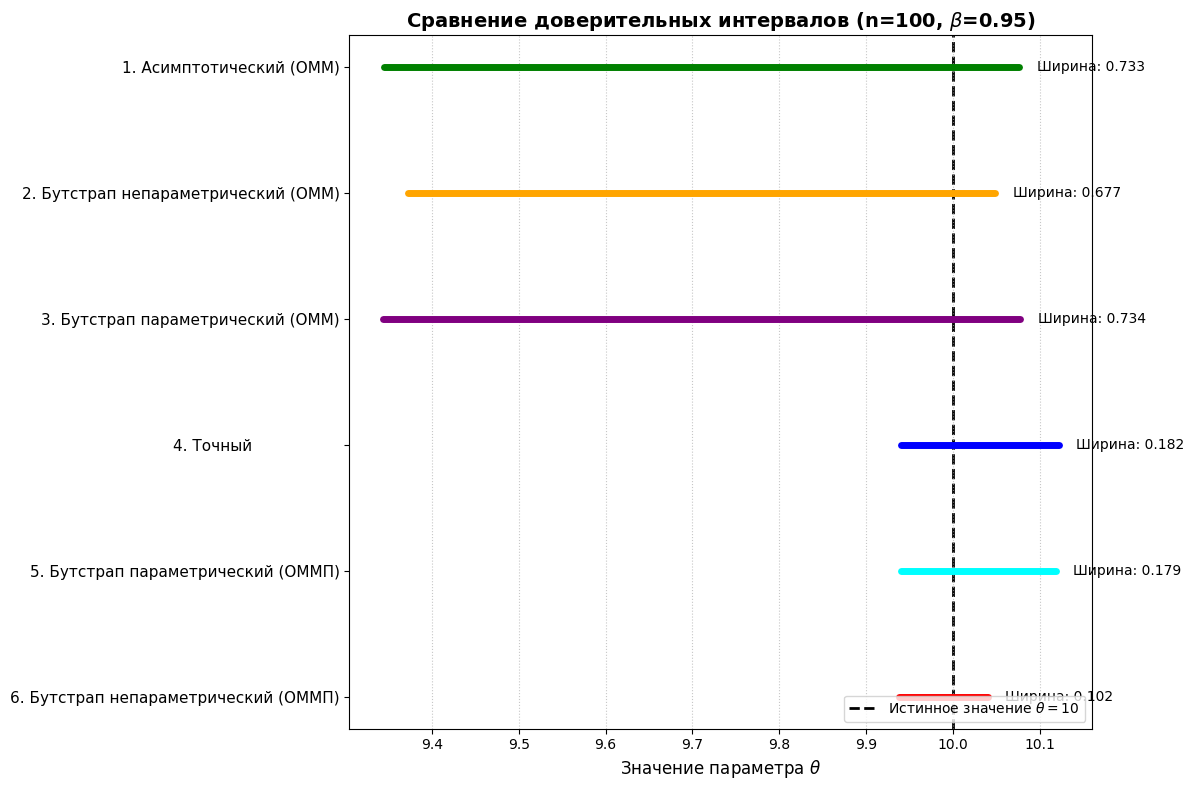

In [59]:
fig, ax = plt.subplots(figsize=(12, 8))

intervals = [
    (ci_mmp_np[0], ci_mmp_np[1], '6. Бутстрап непараметрический (ОММП)', 'red', theta),
    (ci_mmp_p[0], ci_mmp_p[1], '5. Бутстрап параметрический (ОММП)', 'cyan', theta),
    (lower_exact, upper_exact, '4. Точный                  ', 'blue', theta),
    (ci_mm_p[0], ci_mm_p[1], '3. Бутстрап параметрический (ОММ)', 'purple', theta),
    (ci_mm_np[0], ci_mm_np[1], '2. Бутстрап непараметрический (ОММ)', 'orange', theta),
    (lower_asym, upper_asym, '1. Асимптотический (ОММ)', 'green', theta)
]

for i, (left, right, label, color, point_est) in enumerate(intervals):
    y_pos = i + 1
    ax.plot([left, right], [y_pos, y_pos], color=color, linewidth=5, solid_capstyle='round')
    ax.text(right + 0.02, y_pos, f"Ширина: {right-left:.3f}", va='center', fontsize=10)

ax.axvline(x=theta, color='black', linestyle='--', linewidth=2, zorder=0, label=f'Истинное значение $\\theta = {theta}$')

ax.set_yticks(range(1, len(intervals) + 1))
ax.set_yticklabels([interv[2] for interv in intervals], fontsize=11)
ax.set_xlabel('Значение параметра $\\theta$', fontsize=12)
ax.set_title(f'Сравнение доверительных интервалов (n={n}, $\\beta$={beta})', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', linestyle=':', alpha=0.7)

ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# T6
## Генерация выборки n = 100

In [60]:
theta = 3
n = 100
beta = 0.95

np.random.seed(42)
sample = np.random.pareto(theta - 1, n) + 1

sum_log = np.sum(np.log(sample))
theta_mmp = 1 + n / sum_log

print(f"Истинное theta: {theta}")
print(f"Оценка theta (ОМП): {theta_mmp:.4f}")


Истинное theta: 3
Оценка theta (ОМП): 3.1864


## Асимптотический ДИ для theta

In [61]:
u = norm.ppf((1 + beta) / 2)
se_theta = (theta_mmp - 1) / np.sqrt(n)

ci_asy_theta_left = theta_mmp - u * se_theta
ci_asy_theta_right = theta_mmp + u * se_theta

print(f"Асимптотический доверительный интервал для theta: [{ci_asy_theta_left:.4f}; {ci_asy_theta_right:.4f}]")
print(f"Ширина интервала:             {ci_asy_theta_right - ci_asy_theta_left:.4f}")

Асимптотический доверительный интервал для theta: [2.7579; 3.6149]
Ширина интервала:             0.8571


## Асимптотический доверительный интервал для медианы(m)

In [39]:
mediana_mmp = 2 ** (1 / (theta_mmp - 1))
mediana = 2 ** (1 / (theta - 1))

print(f"Истинная медиана: {mediana:.4f}")
print(f"Оценка медианы (ОМП): {mediana_mmp:.4f}\n")

se_m = (mediana_mmp * np.log(2)) / (np.sqrt(n) * (theta_mmp - 1))

ci_asy_m_left = mediana_mmp - u * se_m
ci_asy_m_right = mediana_mmp + u * se_m

print(f"Асимптотический доверительный интервал для медианы: [{ci_asy_m_left:.4f}; {ci_asy_m_right:.4f}]")
print(f"Ширина интервала:               {ci_asy_m_right - ci_asy_m_left:.4f}")

Истинная медиана: 1.4142
Оценка медианы (ОМП): 1.3730

Асимптотический доверительный интервал для медианы: [1.2877; 1.4584]
Ширина интервала:               0.1706


## Бутстраповские доверительные интервалы

In [40]:
N = 50000

deltas_np = np.zeros(N)
deltas_p = np.zeros(N)

for i in range(N):
    # 1. Непараметрический бутстрап (из самой выборки с возвращением)
    boot_np = np.random.choice(sample, size=n, replace=True)
    theta_star_np = 1 + n / np.sum(np.log(boot_np))
    deltas_np[i] = theta_star_np - theta_mmp
    
    # 2. Параметрический бутстрап (генерация новых данных по ОМП)
    boot_p = np.random.pareto(theta_mmp - 1, n) + 1
    theta_star_p = 1 + n / np.sum(np.log(boot_p))
    deltas_p[i] = theta_star_p - theta_mmp

k1 = int((1 - beta) / 2 * N)
k2 = int((1 + beta) / 2 * N)

deltas_np.sort()
deltas_p.sort()

ci_np = [theta_mmp - deltas_np[k2], theta_mmp - deltas_np[k1]]
ci_p = [theta_mmp - deltas_p[k2], theta_mmp - deltas_p[k1]]

print("БУТСТРАПОВСКИЕ ИНТЕРВАЛЫ ДЛЯ ПАРАМЕТРА THETA (ОМП):")
print(f"Непараметрический: [{ci_np[0]:.4f}; {ci_np[1]:.4f}], ширина: {ci_np[1] - ci_np[0]:.4f}")
print(f"Параметрический:   [{ci_p[0]:.4f}; {ci_p[1]:.4f}], ширина: {ci_p[1] - ci_p[0]:.4f}")

БУТСТРАПОВСКИЕ ИНТЕРВАЛЫ ДЛЯ ПАРАМЕТРА THETA (ОМП):
Непараметрический: [2.6767; 3.5548], ширина: 0.8781
Параметрический:   [2.6834; 3.5590], ширина: 0.8756


## Сравнение интервалов

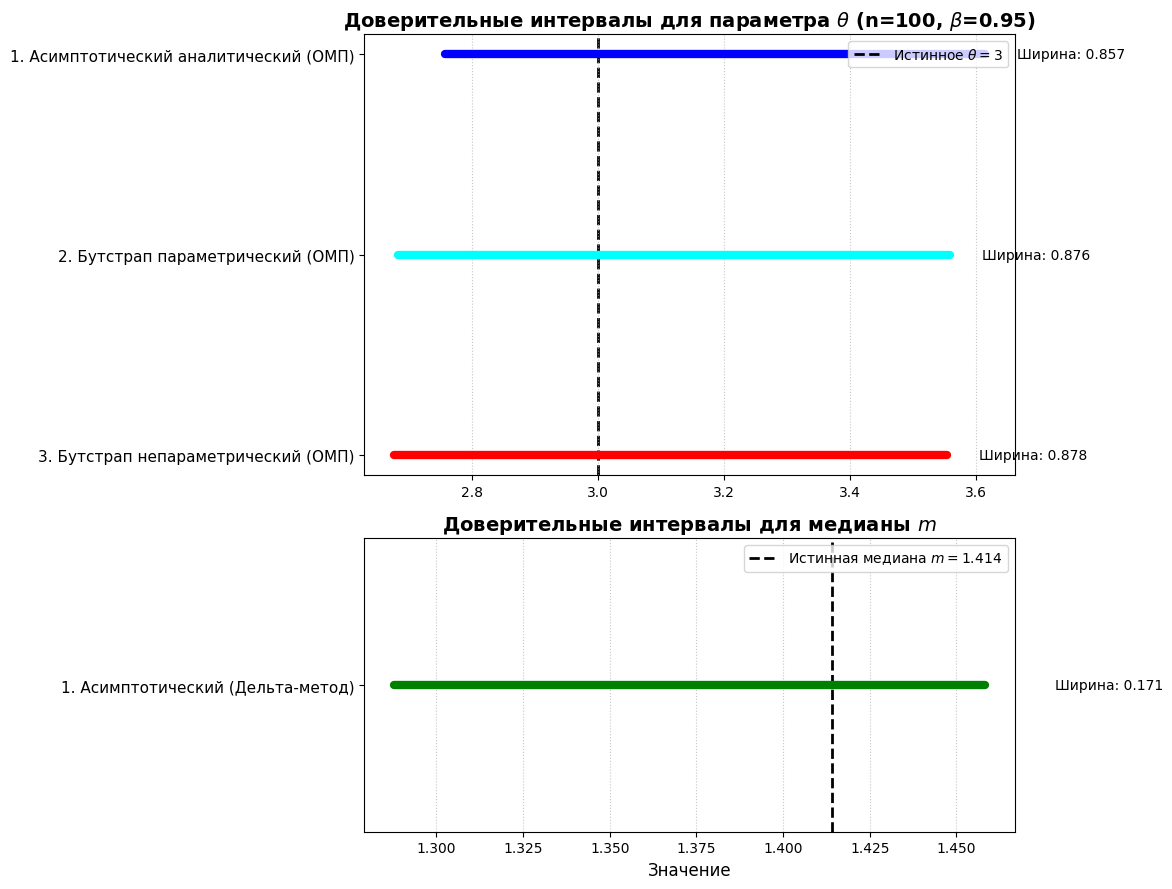

In [41]:
intervals_theta = [
    (ci_np[0], ci_np[1], '3. Бутстрап непараметрический (ОМП)', 'red', theta_mmp),
    (ci_p[0], ci_p[1], '2. Бутстрап параметрический (ОМП)', 'cyan', theta_mmp),
    (ci_asy_theta_left, ci_asy_theta_right, '1. Асимптотический аналитический (ОМП)', 'blue', theta_mmp)
]

# Для медианы m
intervals_median = [
    (ci_asy_m_left, ci_asy_m_right, '1. Асимптотический (Дельта-метод)', 'green', mediana_mmp)
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [1.5, 1]})

# --- График 1: Интервалы для параметра theta ---
for i, (left, right, label, color, point_est) in enumerate(intervals_theta):
    y_pos = i + 1
    ax1.plot([left, right], [y_pos, y_pos], color=color, linewidth=6, solid_capstyle='round')
    ax1.text(right + 0.05, y_pos, f"Ширина: {right-left:.3f}", va='center', fontsize=10)

# Вертикальная линия истинного значения
ax1.axvline(x=theta, color='black', linestyle='--', linewidth=2, zorder=0, label=f'Истинное $\\theta = {theta}$')

# Настройки первого графика
ax1.set_yticks(range(1, len(intervals_theta) + 1))
ax1.set_yticklabels([interv[2] for interv in intervals_theta], fontsize=11)
ax1.set_title(f'Доверительные интервалы для параметра $\\theta$ (n={n}, $\\beta$={beta})', fontsize=14, fontweight='bold')
ax1.grid(True, axis='x', linestyle=':', alpha=0.7)
ax1.legend(loc='upper right')

# --- График 2: Интервалы для медианы m ---
for i, (left, right, label, color, point_est) in enumerate(intervals_median):
    y_pos = i + 1
    ax2.plot([left, right], [y_pos, y_pos], color=color, linewidth=6, solid_capstyle='round')
    ax2.text(right + 0.02, y_pos, f"Ширина: {right-left:.3f}", va='center', fontsize=10)

ax2.axvline(x=mediana, color='black', linestyle='--', linewidth=2, zorder=0, label=f'Истинная медиана $m = {mediana:.3f}$')

# Настройки второго графика
ax2.set_yticks(range(1, len(intervals_median) + 1))
ax2.set_yticklabels([interv[2] for interv in intervals_median], fontsize=11)
ax2.set_xlabel('Значение', fontsize=12)
ax2.set_title(f'Доверительные интервалы для медианы $m$', fontsize=14, fontweight='bold')
ax2.grid(True, axis='x', linestyle=':', alpha=0.7)
ax2.legend(loc='upper right')

# Общие настройки черной точки
ax1.plot([], [], 'ko', label='Точечная оценка (ОМП)')
ax2.plot([], [], 'ko', label='Точечная оценка (ОМП)')

plt.tight_layout()
plt.show()